# Análisis de Datos Clínicos con NumPy y Matplotlib

* **Módulo:** [3.1 Python — Fundamentos para análisis de datos](https://swcarpentry.github.io/python-novice-inflammation/) | **Fecha:** 11 de septiembre de 2026

> **Objetivo:** Implementar un flujo completo de análisis científico con NumPy y Matplotlib: carga de datos tabulares, operaciones estadísticas multidimensionales (`axis`), visualización técnica multieje y detección analítica de anomalías y datos sintéticos.

---

## 1. Carga de datos con NumPy
Importamos las librerías `numpy` y `matplotlib.pyplot`. Utilizamos `np.loadtxt` para cargar el archivo `inflammation-01.csv`. A diferencia de las listas nativas de Python, NumPy almacena los datos en memoria continua como un arreglo `ndarray`, lo que optimiza el rendimiento computacional y permite aplicar operaciones vectorizadas en paralelo.

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Carga de datos tabulares delimitados por comas hacia memoria continua (C-order)
data = np.loadtxt(fname='data/inflammation-01.csv', delimiter=',')

# Inspección de propiedades estructurales del arreglo en memoria
print(f"Tipo de estructura: {type(data)}")
print(f"Dimensiones de la matriz (pacientes, días): {data.shape}")
print(f"Tipo de dato de los elementos: {data.dtype}")
print(f"Total de observaciones registradas: {data.size}")

Tipo de estructura: <class 'numpy.ndarray'>
Dimensiones de la matriz (pacientes, días): (60, 40)
Tipo de dato de los elementos: float64
Total de observaciones registradas: 2400


## 2. Rebanado e indexación de matrices (Slicing 2D)
Para extraer subconjuntos de datos utilizamos la notación matricial `data[filas, columnas]`. Recordando la convención de Python: los índices inician en 0 y los rangos `[inicio:fin)` son semiabiertos (el límite superior queda excluido).

In [56]:
# Acceso a una celda puntual: Paciente 0, Día 0
print(f"Valor inicial (Paciente 0, Día 0): {data[0, 0]}")

# Acceso a una coordenada central: Paciente 30, Día 20
print(f"Valor central (Paciente 30, Día 20): {data[30, 20]}")

# Extracción de una submatriz: primeros 3 pacientes (filas 0 a 2) x primeros 5 días (columnas 0 a 4)
subconjunto = data[0:3, 0:5]
print("\nSubmatriz de muestra (3 pacientes x primeros 5 días):")
print(subconjunto)

Valor inicial (Paciente 0, Día 0): 0.0
Valor central (Paciente 30, Día 20): 13.0

Submatriz de muestra (3 pacientes x primeros 5 días):
[[0. 0. 1. 3. 1.]
 [0. 1. 2. 1. 2.]
 [0. 1. 1. 3. 3.]]


## 3. Reducción estadística por dimensiones (`axis=0` vs `axis=1`)
El parámetro `axis` define la dimensión sobre la cual se colapsa la matriz para calcular las métricas:
* **`axis=0` (colapso vertical por columnas):** Agrega los valores de todos los pacientes para obtener el comportamiento diario global (genera un vector de 40 días).
* **`axis=1` (colapso horizontal por filas):** Agrega los registros diarios de cada individuo para cuantificar la evolución individual de cada paciente (genera un vector de 60 pacientes).

In [57]:
# 1. Agregación a lo largo del eje 0 (comportamiento diario global)
promedio_diario = np.mean(data, axis=0)
maximo_diario = np.max(data, axis=0)
minimo_diario = np.min(data, axis=0)
desviacion_diaria = np.std(data, axis=0)

print(f"Vector de promedios diarios — Longitud: {promedio_diario.shape[0]} días")
print(f"Rango global de inflamación diaria: Mínimo = {minimo_diario.min():.1f} | Máximo = {maximo_diario.max():.1f}")

# 2. Agregación a lo largo del eje 1 (comportamiento individual por paciente)
promedio_pacientes = np.mean(data, axis=1)
print(f"Vector de promedios por paciente — Longitud: {promedio_pacientes.shape[0]} pacientes")

Vector de promedios diarios — Longitud: 40 días
Rango global de inflamación diaria: Mínimo = 0.0 | Máximo = 20.0
Vector de promedios por paciente — Longitud: 60 pacientes


## 4. Inspección global mediante mapa de calor (`imshow`)
El mapa de calor proyecta simultáneamente los 2400 puntos de la matriz asignando una escala de intensidad cromática a los valores de inflamación. Esto permite identificar rápidamente la progresión temporal general del tratamiento y los rangos de dispersión entre individuos.

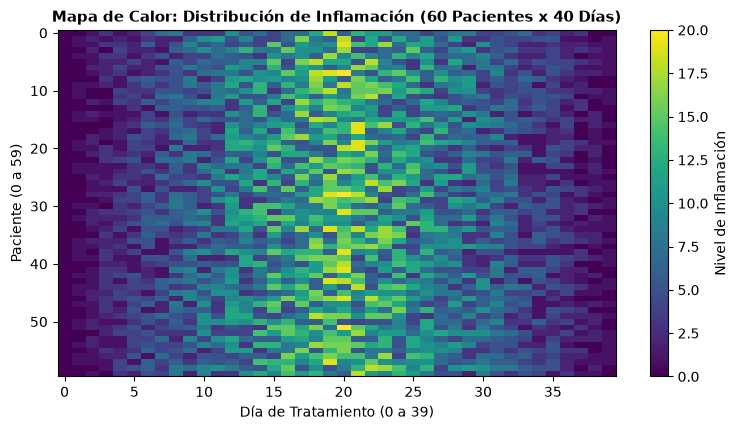

In [58]:
# Visualización completa de la matriz mediante mapa de calor bidimensional
plt.figure(figsize=(9.0, 4.5))
plt.imshow(data, aspect='auto', cmap='viridis')
plt.colorbar(label='Nivel de Inflamación')
plt.title('Mapa de Calor: Distribución de Inflamación (60 Pacientes x 40 Días)', fontsize=11, weight='bold')
plt.xlabel('Día de Tratamiento (0 a 39)', fontsize=10)
plt.ylabel('Paciente (0 a 59)', fontsize=10)
plt.show()

## 5. Visualización técnica multieje (Panel de subplots 1x3)
Construimos un panel comparativo con las tres métricas diarias esenciales (promedio, máximo y mínimo) una al lado de la otra mediante `add_subplot(1, 3, posición)`. Se incorporan cuadrículas auxiliares (`major` y `minor`) y marcadores diferenciados para facilitar la lectura cuantitativa precisa de cada curva.

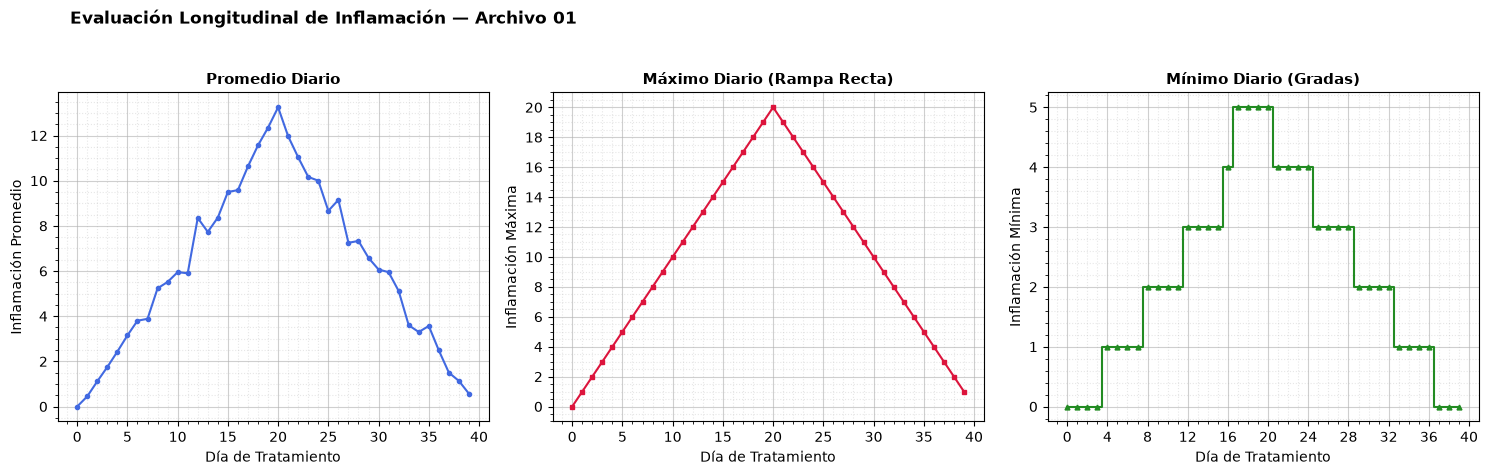

In [59]:
# Configuración del lienzo general para el panel de 3 gráficos (1 fila x 3 columnas)
fig = plt.figure(figsize=(15.0, 4.8))
fig.suptitle('Evaluación Longitudinal de Inflamación — Archivo 01', x=0.05, y=0.98, ha='left', fontsize=12, weight='bold')

# -------------------------------------------------------------------------
# Subplot 1: Promedio Diario de Inflamación
# -------------------------------------------------------------------------
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(range(40), promedio_diario, linestyle='-', marker='o', markersize=3, color='royalblue', label='Promedio')
ax1.set_title('Promedio Diario', fontsize=11, weight='bold')
ax1.set_xlabel('Día de Tratamiento', fontsize=10)
ax1.set_ylabel('Inflamación Promedio', fontsize=10)
ax1.set_xticks(np.arange(0, 41, 5))
ax1.minorticks_on()
ax1.grid(True, which='major', linestyle='-', alpha=0.6)
ax1.grid(True, which='minor', linestyle=':', alpha=0.3)

# -------------------------------------------------------------------------
# Subplot 2: Máximo Diario (Perfil de Rampa Lineal)
# -------------------------------------------------------------------------
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(range(40), maximo_diario, linestyle='-', marker='s', markersize=3, color='crimson', label='Máximo')
ax2.set_title('Máximo Diario (Rampa Recta)', fontsize=11, weight='bold')
ax2.set_xlabel('Día de Tratamiento', fontsize=10)
ax2.set_ylabel('Inflamación Máxima', fontsize=10)
ax2.set_xticks(np.arange(0, 41, 5))
ax2.set_yticks(np.arange(0, 21, 2))
ax2.minorticks_on()
ax2.grid(True, which='major', linestyle='-', alpha=0.6)
ax2.grid(True, which='minor', linestyle=':', alpha=0.3)

# -------------------------------------------------------------------------
# Subplot 3: Mínimo Diario (Perfil de Escalones Discretos)
# -------------------------------------------------------------------------
ax3 = fig.add_subplot(1, 3, 3)
ax3.step(range(40), minimo_diario, where='mid', color='forestgreen', linewidth=1.5)
ax3.plot(range(40), minimo_diario, linestyle='none', marker='^', markersize=3.5, color='forestgreen', label='Mínimo')
ax3.set_title('Mínimo Diario (Gradas)', fontsize=11, weight='bold')
ax3.set_xlabel('Día de Tratamiento', fontsize=10)
ax3.set_ylabel('Inflamación Mínima', fontsize=10)
ax3.set_xticks(np.arange(0, 41, 4))
ax3.set_yticks(np.arange(0, 6, 1))
ax3.minorticks_on()
ax3.grid(True, which='major', linestyle='-', alpha=0.6)
ax3.grid(True, which='minor', linestyle=':', alpha=0.3)

# Ajuste automático de márgenes para evitar solapamientos
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 6. Modularización: Funciones para análisis automatizado
Encapsulamos la lógica en funciones reutilizables para garantizar un flujo reproducible:
1. `detectar_anomalias(data)`: Evalúa reglas heurísticas para identificar comportamientos matemáticos anómalos en los registros (como rampas artificiales o sensores inactivos).
2. `analizar(filename)`: Automatiza la carga del archivo, la auditoría clínica y la generación del panel gráfico correspondiente.

In [ ]:
def detectar_anomalias(data):
    """
    Audita la matriz de datos para detectar comportamientos matemáticos anómalos.

    Parámetros:
        data (np.ndarray): Matriz bidimensional de datos clínicos (pacientes x días).
    """
    max_diario = np.max(data, axis=0)
    min_diario = np.min(data, axis=0)

    # Condición 1: Rampa lineal artificial en máximos
    if max_diario[0] == 0 and max_diario[20] == 20:
        print('  ⚠️  ALERTA: Los valores máximos forman una rampa lineal artificial.')
    # Condición 2: Sensores o registros bloqueados en cero absoluto
    elif np.sum(min_diario) == 0:
        print('  ⚠️  ALERTA: Los valores mínimos son cero todos los días (posible falla de sensor).')
    else:
        print('  ✅  COMPORTAMIENTO: Los datos parecen biológicamente naturales.')


def analizar(filename):
    """
    Carga un archivo CSV, ejecuta la detección de anomalías y genera el panel de subplots.

    Parámetros:
        filename (str): Ruta al archivo tabular CSV.
    """
    print(f"\n{'=' * 50}")
    print(f"AUDITORÍA CLÍNICA: {filename}")
    print(f"{'=' * 50}")

    # Carga de la matriz de datos del archivo correspondiente
    data = np.loadtxt(fname=filename, delimiter=',')
    detectar_anomalias(data)

    # Construcción del panel de visualización técnica
    fig = plt.figure(figsize=(15.0, 4.5))
    fig.suptitle(f'Estudio Clínico: {filename}', x=0.05, y=0.98, ha='left', fontsize=12, weight='bold')

    # Panel 1: Promedio
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(range(40), np.mean(data, axis=0), linestyle='-', marker='o', markersize=3, color='royalblue')
    ax1.set_title('Promedio Diario', fontsize=10, weight='bold')
    ax1.set_xlabel('Día de Tratamiento', fontsize=9)
    ax1.set_ylabel('Inflamación', fontsize=9)
    ax1.minorticks_on()
    ax1.grid(True, which='major', linestyle='-', alpha=0.5)
    ax1.grid(True, which='minor', linestyle=':', alpha=0.25)

    # Panel 2: Máximo
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.plot(range(40), np.max(data, axis=0), linestyle='-', marker='s', markersize=3, color='crimson')
    ax2.set_title('Máximo Diario', fontsize=10, weight='bold')
    ax2.set_xlabel('Día de Tratamiento', fontsize=9)
    ax2.minorticks_on()
    ax2.grid(True, which='major', linestyle='-', alpha=0.5)
    ax2.grid(True, which='minor', linestyle=':', alpha=0.25)

    # Panel 3: Mínimo
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.step(range(40), np.min(data, axis=0), where='mid', color='forestgreen')
    ax3.plot(range(40), np.min(data, axis=0), linestyle='none', marker='^', markersize=3.5, color='forestgreen')
    ax3.set_title('Mínimo Diario', fontsize=10, weight='bold')
    ax3.set_xlabel('Día de Tratamiento', fontsize=9)
    ax3.minorticks_on()
    ax3.grid(True, which='major', linestyle='-', alpha=0.5)
    ax3.grid(True, which='minor', linestyle=':', alpha=0.25)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## 7. Procesamiento sistemático por lotes (`glob`)
Utilizamos el módulo estándar `glob` para localizar dinámicamente los archivos que coinciden con el patrón `inflammation-*.csv` y ordenarlos con `sorted()`. Con un bucle `for`, auditamos los tres primeros archivos del estudio clínico de manera consecutiva.

Total de archivos detectados en lote: 12

AUDITORÍA CLÍNICA: data\inflammation-01.csv
  ⚠️  ALERTA: Los valores máximos forman una rampa lineal artificial.


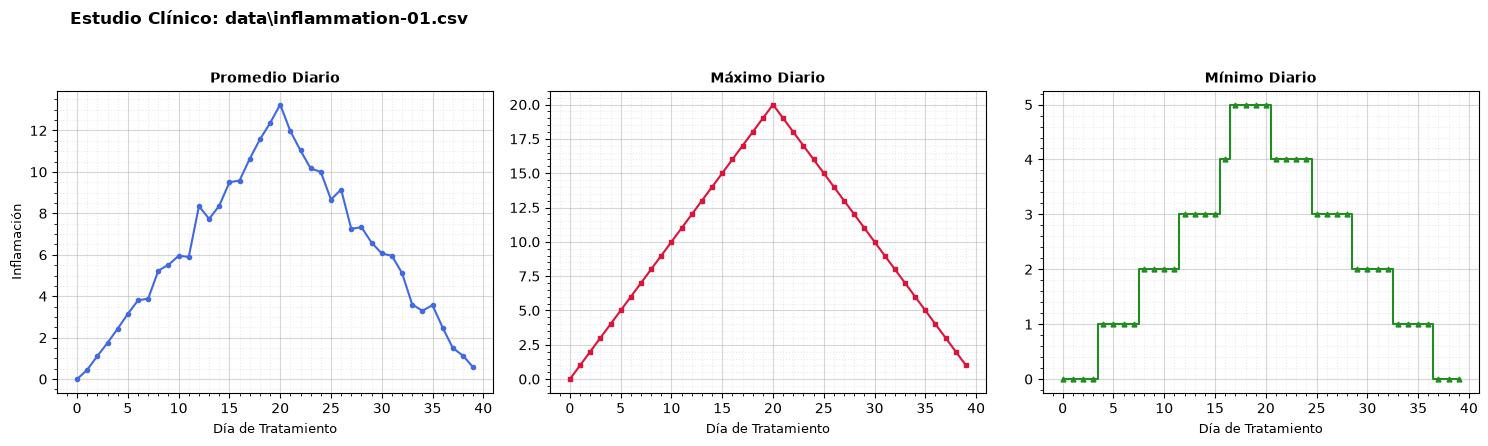


AUDITORÍA CLÍNICA: data\inflammation-02.csv
  ⚠️  ALERTA: Los valores máximos forman una rampa lineal artificial.


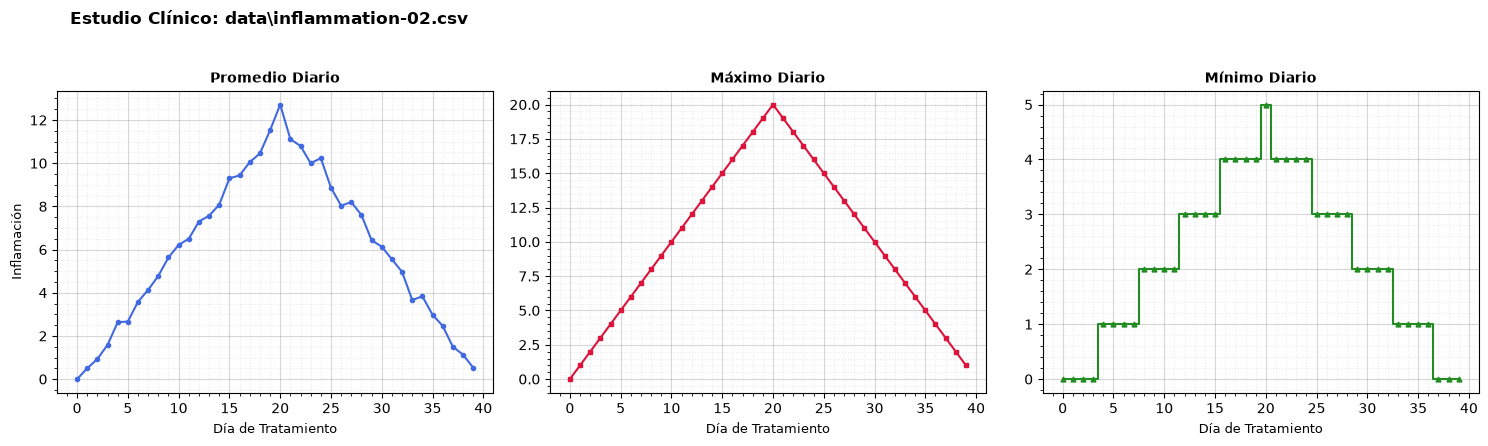


AUDITORÍA CLÍNICA: data\inflammation-03.csv
  ⚠️  ALERTA: Los valores mínimos son cero todos los días (posible falla de sensor).


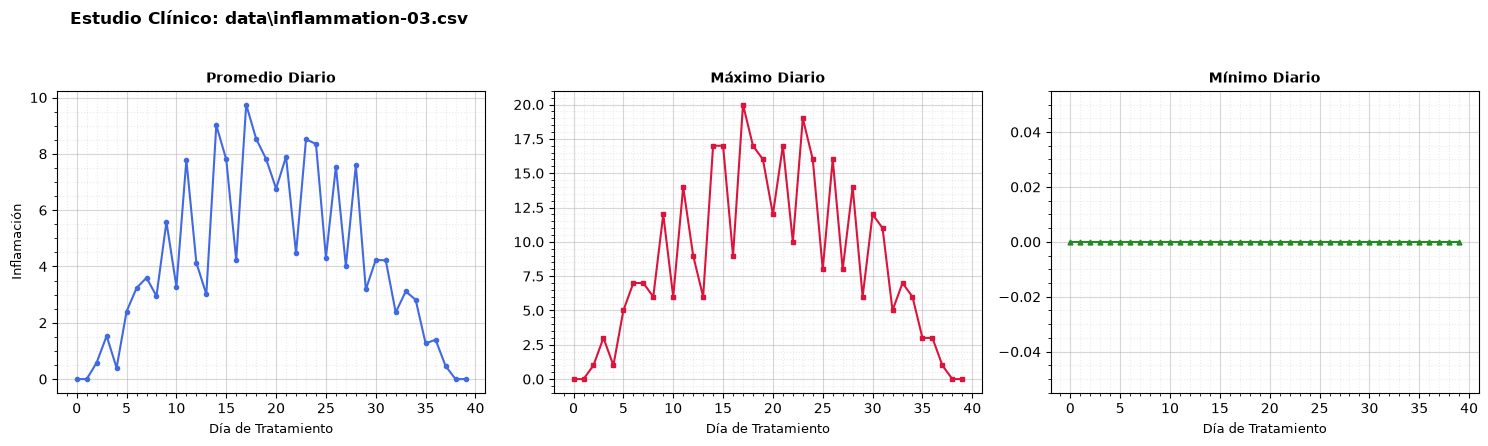

In [61]:
import glob

# Identificación determinista y ordenada de archivos de datos
archivos = sorted(glob.glob('data/inflammation-*.csv'))
print(f"Total de archivos detectados en lote: {len(archivos)}")

# Ejecución del pipeline sobre muestra de control (primeros 3 archivos)
for f in archivos[:3]:
    analizar(f)

## 8. Verificación analítica de datos sintéticos (`np.diff`)
Para comprobar matemáticamente si la rampa en el archivo 01 proviene de una función artificial en lugar de una respuesta biológica real, calculamos la derivada discreta con `np.diff()`. Una tasa de cambio estrictamente constante e idéntica a 1.0 en la fase de ascenso confirma una generación algorítmica sintética.

In [62]:
# Extracción de máximos del archivo 01
data_01 = np.loadtxt(fname='data/inflammation-01.csv', delimiter=',')
maximos_01 = np.max(data_01, axis=0)

# Cálculo de diferencias consecutivas (derivada discreta) durante los primeros 20 días
diferencias = np.diff(maximos_01[:21])
print("Diferencias consecutivas entre días adyacentes (días 0 al 20):")
print(diferencias)

# Verificación booleana de constancia unitaria
es_recta_perfecta = np.all(diferencias == 1.0)
print(f"\n¿Pendiente estrictamente constante e idéntica a 1.0?: {es_recta_perfecta}")

Diferencias consecutivas entre días adyacentes (días 0 al 20):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

¿Pendiente estrictamente constante e idéntica a 1.0?: True


## 9. Conclusiones y Diagnóstico del Estudio

1. **Eficiencia y vectorización:** El uso de arreglos `ndarray` de NumPy evita bucles `for` tradicionales y aprovecha la contigüidad en memoria para cálculos numéricos de alto rendimiento.
2. **Operaciones por dimensiones:** La parametrización adecuada de `axis` es indispensable en ciencia de datos para desacoplar el análisis longitudinal (temporal por día) del transversal (por paciente).
3. **Visualización diagnóstica:** El diseño de subplots con escalas, cuadrículas calibradas y estilos diferenciados permite contrastar hipótesis y descubrir patrones que una tabla numérica oculta.
4. **Detección forense de datos sintéticos:** El análisis estadístico y diferencial demostró que los archivos `inflammation-01.csv` e `inflammation-02.csv` fueron generados sintéticamente mediante fórmulas discretas deterministas (rampas lineales y gradas fijas de 4 días), mientras que `inflammation-03.csv` presenta una falla instrumental o de captura (mínimos nulos continuos).